In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import ellipk
from scipy.signal import find_peaks, peak_widths
from scipy.constants import mu_0, epsilon_0
from scipy.optimize import root, curve_fit
from functools import partial
from scipy.io import loadmat
from scipy.optimize import least_squares

In [3]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [4]:
import h5py

In [5]:
def del_sol(delta, a, phi_ext_val):
    
    lhs = delta + a * np.sin(delta)
    
    return lhs - phi_ext_val


# calculates the impedance of the coupling capacitor to the transmission line (not shown in the setup)
def c_cap(c_c, w):
    return np.array([[1,1/(1j*c_c*w)],[0,1]])

# calculates the impedance of the resonator
def tline(Z0, beta, L):
    return np.array([[np.cos(beta*L),1j*Z0*np.sin(beta*L)],[1j*(1/Z0)*np.sin(beta*L),np.cos(beta*L)]])


def Z_L(L_01, L_02, L_T, d, w, R):
    ZL01 = 1j*w*L_01
    ZL02 = 1j*w*L_02
    ZLT = 1j*w*L_T/np.cos(d)
    ZL02R = (1/ZL02 + 1/R)**(-1)
    ZSQUID = (1/ZL01 + 1/(ZLT + ZL02R))**(-1)
    
    return ZSQUID

def Z_tot(ZL, Z0, beta, l, c_c, w):
    x = beta*l
    Z_c = 1/(1j*w*c_c)
    return (Z0*((ZL + 1j*Z0*np.tan(x))/(Z0 + 1j*ZL*np.tan(x)))) + Z_c

def branch(Z):
    return np.array([[1,0], [1/Z, 1]])
    
#calculates the ABCD matrix
def ABCD(M1, M2, M3):
    full_M = M1 @ M2 @ M3 
    
    return full_M
#Calculates the S21 parameter
def S21(A, B, C, D, Z0):
    return 2/(A + B/Z0 + C*Z0 + D)


def current_to_flux(I, M, o):
    return M*I + o


In [6]:
def solve_delta(phi_ext, a):
    phi_ext = np.asarray(phi_ext)
    delta = np.zeros_like(phi_ext, dtype=float)
    order = np.argsort(phi_ext)          # continuity in phi_ext, not array position
    d0 = 0.0
    for idx in order:
        sol = root(del_sol, d0, args=(a, phi_ext[idx]))
        delta[idx] = sol.x[0]
        d0 = sol.x[0]
    return delta

def S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, Z0=50):
    """
    X = (I, f): current (A) and frequency (Hz) arrays, same length (elementwise pairs).
    Fit params: L0 (=L01=L02), LT, L_l, C_l, C_c, R_j
    Fixed:      l_f (resonator length), M, O (current -> flux calibration)
    """
    I, f = X
    w = 2 * np.pi * f
    phi_ext = M * I + O #np.pi - 0.5 -0.25 - 0.25 - 0.25

    a = 2 * L0 / LT
    delta = solve_delta(phi_ext, a)

    beta = w * np.sqrt(L_l * C_l)
    ZL = Z_L(L0, L0, LT, delta, w, R_j)
    Ztot = Z_tot(ZL, Z0, beta, l_f, C_c, w)

    return 2 / (2 + Z0 / Ztot)

def S21_fit_mag_dB(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f):
    S21 = S21_fit_func(X, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f)
    return 20 * np.log10(np.abs(S21))

In [7]:
def calc_cpw_param_set(
    center_width: float, gap_width: float, substrate_r: float, metal_thickness: float
):
    a = center_width / 2
    b = center_width / 2 + gap_width
    d = metal_thickness / (2 * np.pi)

    u1 = (
        a
        + d / 2
        + 3 / 2 * np.log(2) * d
        - d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    u2 = (
        b
        - d / 2
        - 3 / 2 * np.log(2) * d
        + d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    k1 = u1 / u2
    k2 = np.sqrt(1 - k1**2)
    c = 2 * epsilon_0 * ellipk(k1) / ellipk(k2) * (1 + substrate_r)

    d = d/2
    u1 = a+d/2+3/2*np.log(2)*d-d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    u2 = b-d/2-3/2*np.log(2)*d+d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    k1 = u1/u2
    k2 = np.sqrt(1-k1**2)
    l = mu_0/4*ellipk(k2)/ellipk(k1)

    lambda_eff = 50e-9  # m, effective field penetration depth
    k = a/b
    g_ctr = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*a/metal_thickness)-k*np.log((1+k)/(1-k)))
    g_gnd = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*b/metal_thickness)-k*np.log((1+k)/(1-k)))
    g = g_ctr+g_gnd
    l_ki = g*mu_0*lambda_eff
    l_tot = l+l_ki

    return {'inductance': l_tot, 'capacitance': c}

def calc_target_length(target_frequency: float, cpw_param_set: dict):
    return 1e6 / (4 * target_frequency * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))



def calc_target_frequency(target_length: float, cpw_param_set: dict):
    return 1e6 / (4 * target_length * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))



resonator_widths = [7, 10, 7]
#################################3

res_cpw_param_set = calc_cpw_param_set(
    center_width= resonator_widths[1]*1e-6, 
    gap_width=resonator_widths[0]*1e-6, 
    substrate_r=11.6, 
    metal_thickness=200e-9
)
l = calc_target_length(5.5e9, res_cpw_param_set)
R_L = l/1e6
L_l = res_cpw_param_set['inductance']
C_l = res_cpw_param_set['capacitance']
R_L

np.float64(0.005122618693762872)

In [8]:
mat_data_s21 = loadmat('TC-Main-001-S21-Fit-test1.mat', squeeze_me=True)
mat_data_freq = loadmat('Tc-Main-001-F-fit-test1.mat', squeeze_me=True)
mat_data_current = loadmat('TC-Main-001-I-fit-test1.mat', squeeze_me = True)
mat_data_f0 = loadmat('TC-Main-001-f0-fit-all.mat', squeeze_me = True)
mat_data_I1 = loadmat('TC-Main-001-I1-fit-all.mat', squeeze_me = True)
mat_data_Q_ext = loadmat('TC-Main-001-Q-ext-fit-all.mat', squeeze_me = True)
mat_data_Q_L = loadmat('TC-Main-001-Q-L-fit-all.mat', squeeze_me = True)
mat_data_Q_int = loadmat('TC-Main-001-Q-int-fit-all.mat', squeeze_me = True)

In [9]:
S21_dB = mat_data_s21['S21_fit'] 
Freq = mat_data_freq['F_fit']
I1 = mat_data_current['I_fit']
f0_all = mat_data_f0['f0_all']
I1_all = mat_data_I1['I1_all']
Q_ext_all = mat_data_Q_ext['Qext_all']
Q_L_all = mat_data_Q_L['QL_all']
Q_int_all = mat_data_Q_int['Qi_all']

In [10]:
def lorentzian_dip_power(f, f0, Q_L, baseline, Q_e_inv):
    """
    Fit model for |S21|^2 in terms of Q factors directly.
    Q_e_inv = 1/Q_e (easier to fit as a free parameter)
    """
    depth_amplitude = Q_L * Q_e_inv          # = Q_L / Q_e
    lorentz = depth_amplitude / (1 + 4 * Q_L**2 * ((f - f0)/f0)**2)
    # |S21|^2 = baseline * |1 - lorentz|^2
    return baseline * (1 - lorentz)**2


def calculate_q_factors(freq, S21_vals):

    # Ensure freq is a flat 1D array
    #freq = np.asarray(freq).flatten()
    n_flux = S21_vals.shape[1]
    
    q_loaded = np.zeros(n_flux)
    q_internal = np.zeros(n_flux)
    q_external = np.zeros(n_flux)
    f0_fits = np.zeros(n_flux)
    
    for i in range(n_flux):
        power = np.abs(S21_vals[:, i])**2
        
        baseline_guess = np.max(power)
        min_idx = np.argmin(power)
        f0_guess = freq[min_idx]
        S21_min = np.sqrt(power[min_idx] / baseline_guess)
        
        # Estimate df (FWHM) by finding points below the half-depth
        half_max = baseline_guess - (baseline_guess - power[min_idx]) / 2.0
        below_half = np.where(power < half_max)[0]
        
        df_guess = freq[below_half[-1]] - freq[below_half[0]]

        Q_L_guess = f0_guess/df_guess
        
        dip = np.clip(1.0-S21_min, 1e-6, 2.0)
        Qe_inv_guess = dip/Q_L_guess
                 
        p0 = [f0_guess, Q_L_guess, baseline_guess, Qe_inv_guess]
        
        popt, _ = curve_fit(lorentzian_dip_power, freq, power,
                            p0=p0, maxfev=2000)
        f0_fit, Q_L_fit, _, Qe_inv_fit = popt
        Q_L_fit = np.abs(Q_L_fit)
        Q_e_fit = 1.0 / np.abs(Qe_inv_fit)
        
        Q_i_fit = 1.0 / (1.0/Q_L_fit - 1.0/Q_e_fit)

        q_loaded[i]   = Q_L_fit
        q_external[i] = Q_e_fit
        q_internal[i] = Q_i_fit
        f0_fits[i]    = f0_fit

    return q_loaded, q_internal, q_external, f0_fits

In [11]:
def model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O, l_f, f_bounds, n_freq=400):
    """Generate dense model S21 per current, extract Q_i/Q_ext/f0 via the same
    Lorentzian-fit machinery used on the real data."""
    f_dense = np.linspace(*f_bounds, n_freq)
    S21_grid = np.zeros((n_freq, len(I_arr)), dtype=complex)

    for k, I_val in enumerate(I_arr):
        S21_grid[:, k] = S21_fit_func(
            (np.full(n_freq, I_val), f_dense),
            L0, LT, L_l, C_l, C_c, R_j, M, O, l_f
        )

    q_L, q_i, q_e, f0_arr = calculate_q_factors(f_dense, S21_grid)
    return q_L, q_i, q_e, f0_arr

In [12]:

# def pole_weights(I_arr_uA, M, O, sharpness=8):
#     """Smoothly down-weight points near phi_ext = pi (mod 2*pi), where the model's
#     pole makes exact matching both unreliable in the data and unnecessary to fit."""
#     phi_ext = M * (I_arr_uA * 1e-6) + O
#     dist = np.abs(np.mod(phi_ext - np.pi + np.pi, 2*np.pi) - np.pi)  # distance to nearest pi (mod 2pi)
#     # smooth taper: weight -> 0 right at the pole, -> 1 a bit away from it
#     w = 1 - np.exp(-sharpness * dist**2)
#     return np.clip(w, 0.05, 1.0)


def summary_residuals_QL_f0(params, I_arr, QL_data, f0_data, Qext_all,l_f, f_bounds, O_fixed):
    L0, LT, L_l, C_l, C_c, R_j, M = params
    try:
        q_L, q_i, q_e, f0 = model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O_fixed, l_f, f_bounds)
    except RuntimeError:
        return np.full(3*len(I_arr), 1e3)

    # w = pole_weights(I_arr*1e6, M, O_fixed)

    res_QL = (np.log10(q_L) - np.log10(QL_data)) #* w
    res_f0 = ((f0 - f0_data) / 1e6) #* w
    #res_Qe = (np.log10(q_e) - np.log10(Qext_all)) #* w

    return np.concatenate([res_QL, res_f0])


O_fixed = np.pi - 1.25
M_mag = 2*np.pi / 2.15e-6  
#L_l = 4.9137e-7
#C_l = 1.2861e-10

p0 = [0.17e-9, 0.38e-9, L_l, C_l, 53.5e-15, 18, M_mag]
lower = [0.15e-9, 0.37e-9, 0.6*L_l, 0.6*C_l, 52e-15, 15,  -1.1*M_mag]
upper = [0.18e-9, 0.42e-9, 1.1*L_l, 1.1*C_l, 55e-15, 20, 1.1*M_mag]

res = least_squares(
    summary_residuals_QL_f0, p0,
    args=(I1_all*1e-6, Q_L_all, f0_all, Q_ext_all, R_L, (Freq.min(), Freq.max()), O_fixed),
    bounds=(lower, upper), x_scale='jac'
)
L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f = res.x
print(res.x, " a =", 2*L0_f/LT_f, " cost:", res.cost)

[1.66717728e-10 4.12745249e-10 4.96034062e-07 1.27399627e-10
 5.34986960e-14 1.96113819e+01 2.89456081e+06]  a = 0.807848078735145  cost: 9199.057131032205


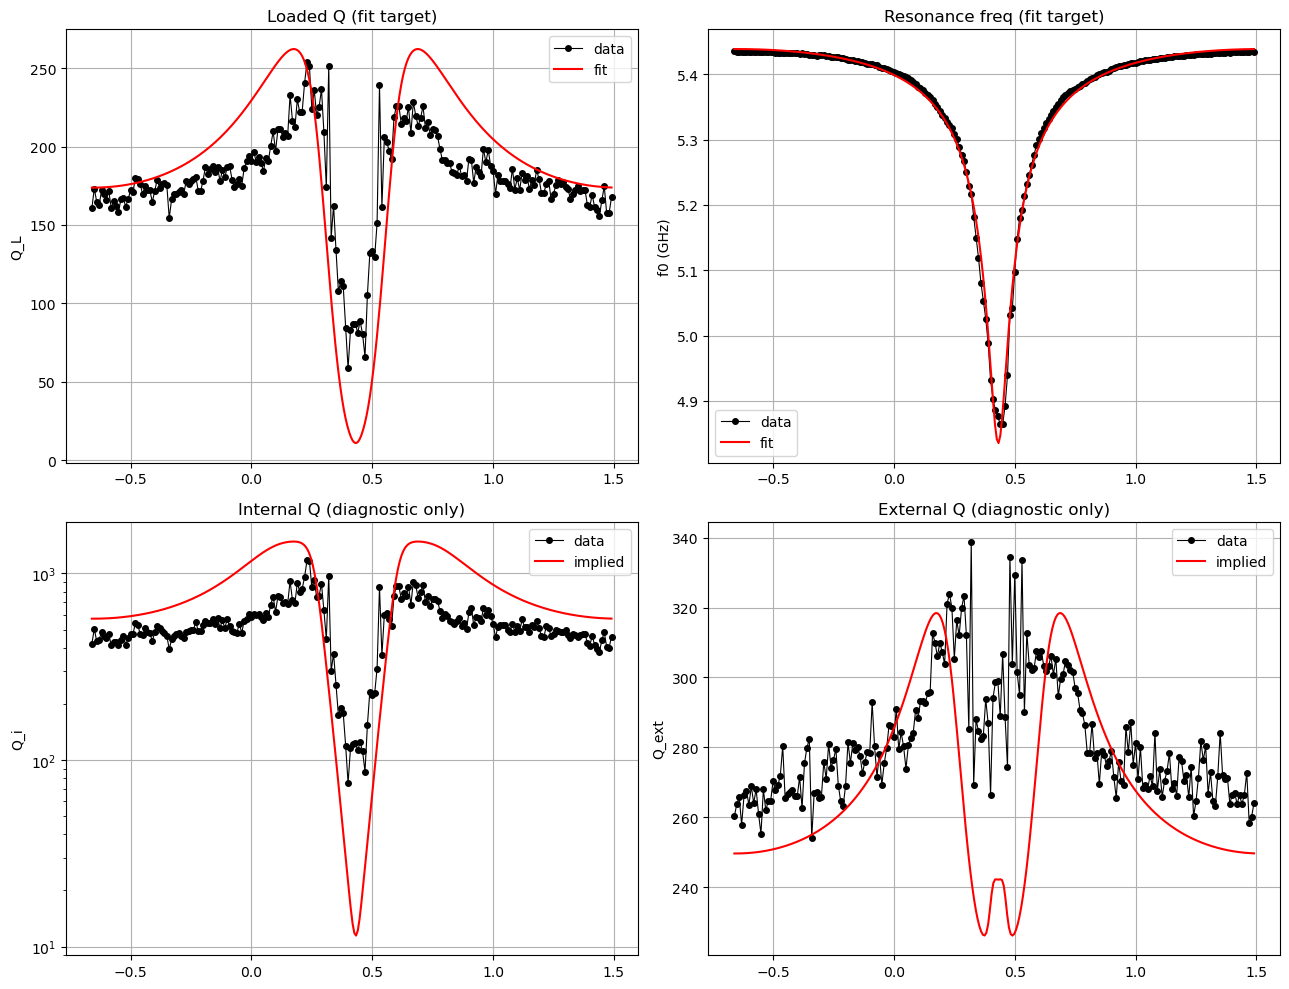

In [13]:
I_plot_uA = np.linspace(I1_all.min(), I1_all.max(), 300)
I_plot_A = I_plot_uA * 1e-6
QL_model, q_i_model, q_e_model, f0_model = model_q_factors(
    I_plot_A, L0_f, LT_f, Ll_f, Cl_f, Cc_f, Rj_f, M_f, O_fixed, R_L, (Freq.min(), Freq.max())
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes[0,0].plot(I1_all, Q_L_all, 'ko-', ms=4, lw=0.8, label='data')
axes[0,0].plot(I_plot_uA, QL_model, 'r-', lw=1.5, label='fit')
axes[0,0].set_ylabel('Q_L'); axes[0,0].set_title('Loaded Q (fit target)'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(I1_all, f0_all/1e9, 'ko-', ms=4, lw=0.8, label='data')
axes[0,1].plot(I_plot_uA, f0_model/1e9, 'r-', lw=1.5, label='fit')
axes[0,1].set_ylabel('f0 (GHz)'); axes[0,1].set_title('Resonance freq (fit target)'); axes[0,1].legend(); axes[0,1].grid(True)

axes[1,0].plot(I1_all, Q_int_all, 'ko-', ms=4, lw=0.8, label='data')
axes[1,0].plot(I_plot_uA, q_i_model, 'r-', lw=1.5, label='implied')
axes[1,0].set_ylabel('Q_i'); axes[1,0].set_yscale('log'); axes[1,0].set_title('Internal Q (diagnostic only)'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(I1_all, Q_ext_all, 'ko-', ms=4, lw=0.8, label='data')
axes[1,1].plot(I_plot_uA, q_e_model, 'r-', lw=1.5, label='implied')
axes[1,1].set_ylabel('Q_ext'); axes[1,1].set_title('External Q (diagnostic only)'); axes[1,1].legend(); axes[1,1].grid(True)
plt.tight_layout(); plt.show()

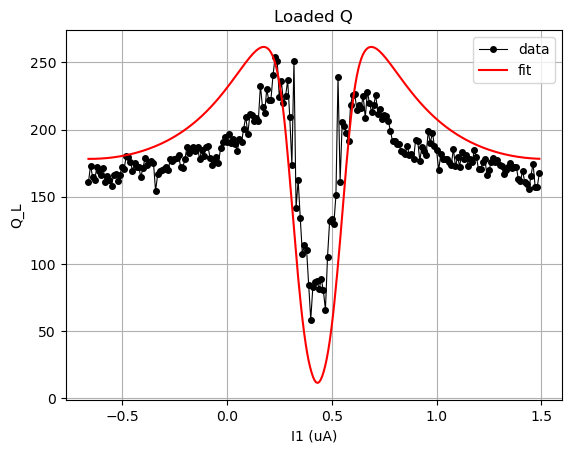

In [14]:
plt.plot(I1_all, Q_L_all, 'ko-', ms=4, lw=0.8, label='data')
plt.plot(I_plot_uA, QL_model, 'r-', lw=1.5, label='fit')
plt.xlabel('I1 (uA)')
plt.ylabel('Q_L')
plt.title('Loaded Q')
plt.legend()
plt.grid(True)


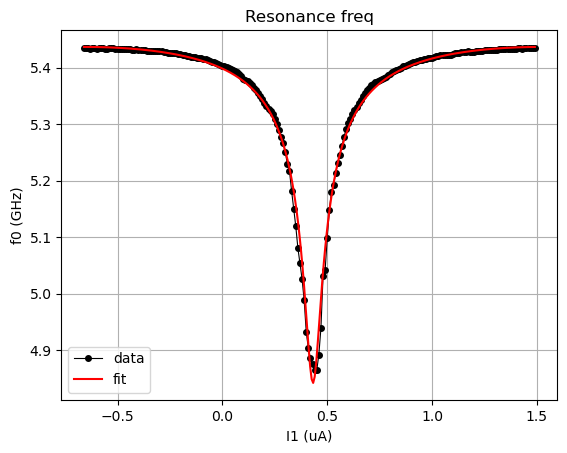

In [15]:
plt.plot(I1_all, f0_all/1e9, 'ko-', ms=4, lw=0.8, label='data')
plt.plot(I_plot_uA, f0_model/1e9, 'r-', lw=1.5, label='fit')
plt.xlabel('I1 (uA)')
plt.ylabel('f0 (GHz)')
plt.title('Resonance freq')
plt.legend()
plt.grid(True)

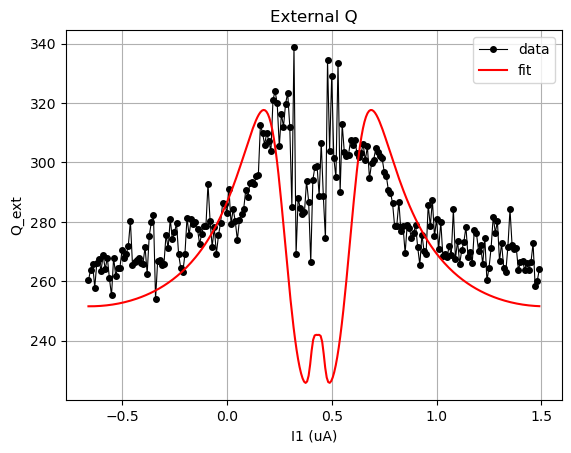

In [18]:
plt.plot(I1_all, Q_ext_all, 'ko-', ms=4, lw=0.8, label='data')
plt.plot(I_plot_uA, q_e_model, 'r-', lw=1.5, label='fit')
plt.xlabel('I1 (uA)')
plt.ylabel('Q_ext')
plt.title('External Q')
plt.legend()
plt.grid(True)

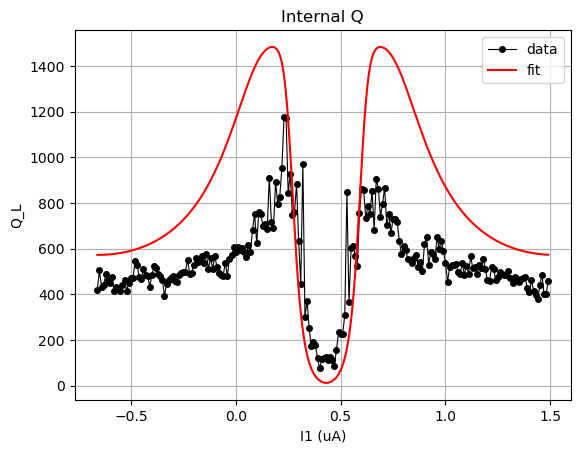

In [15]:
plt.plot(I1_all, Q_int_all, 'ko-', ms=4, lw=0.8, label='data')
plt.plot(I_plot_uA, q_i_model, 'r-', lw=1.5, label='fit')
plt.xlabel('I1 (uA)')
plt.ylabel('Q_L')
plt.title('Internal Q')
plt.legend()
plt.grid(True)

Fitted parameters with 1-sigma uncertainty:
  L0    = 1.6672e-10  +/- 8.47e-12
  LT    = 4.1275e-10  +/- 5.07e-12
  L_l   = 4.9603e-07  +/- 4.65e-08
  C_l   = 1.2740e-10  +/- 2.01e-12
  C_c   = 5.3499e-14  +/- 3.83e-14
  R_j   = 1.9611e+01  +/- 9.32e+00
  M     = 2.8946e+06  +/- 2.45e+03


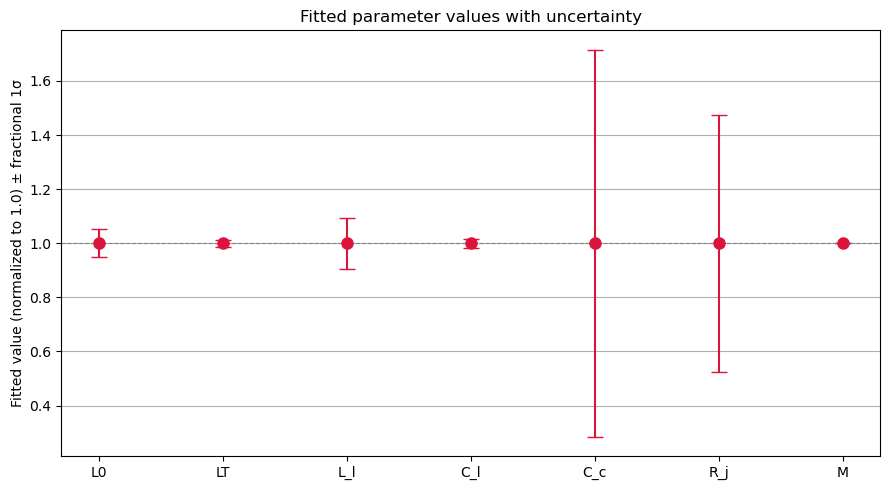

In [17]:
# --- Compute parameter uncertainties from the Jacobian ---
J = res.jac
residual_variance = np.sum(res.fun**2) / (len(res.fun) - len(res.x))  # reduced chi-square estimate
try:
    cov = residual_variance * np.linalg.inv(J.T @ J)
    perr = np.sqrt(np.diag(cov))
except np.linalg.LinAlgError:
    perr = np.full(len(res.x), np.nan)
    print("Warning: J^T J is singular, covariance could not be computed -- some parameters may be poorly constrained/degenerate.")

param_names = ['L0', 'LT', 'L_l', 'C_l', 'C_c', 'R_j', 'M']
print("Fitted parameters with 1-sigma uncertainty:")
for name, val, err in zip(param_names, res.x, perr):
    print(f"  {name:5s} = {val:.4e}  +/- {err:.2e}")

# --- Error bar plot: normalize each parameter to its fitted value so they're comparable on one axis ---
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(param_names))
rel_err = perr / np.abs(res.x)   # fractional uncertainty, dimensionless -- lets very different scales share an axis

ax.errorbar(x_pos, np.ones(len(param_names)), yerr=rel_err, fmt='o', ms=8, capsize=6, color='crimson')
ax.set_xticks(x_pos)
ax.set_xticklabels(param_names)
ax.axhline(1.0, color='gray', lw=0.8, ls='--')
ax.set_ylabel('Fitted value (normalized to 1.0) ± fractional 1σ')
ax.set_title('Fitted parameter values with uncertainty')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [20]:
res.x

array([1.66717728e-10, 4.12745249e-10, 4.96034062e-07, 1.27399627e-10,
       5.34986960e-14, 1.96113819e+01, 2.89456081e+06])

In [39]:
corr = cov / np.outer(perr, perr)   # normalize covariance into correlation matrix
print("Correlation between C_c and R_j:", corr[4, 5])  # indices 4=C_c, 5=R_j in your param_names list

Correlation between C_c and R_j: 0.05402432765270539


In [49]:
corr = cov / np.outer(perr, perr)
print("Correlation matrix (rows/cols = L0, LT, L_l, C_l, C_c, R_j, M):")
print(np.round(corr, 2))
print("\nC_c <-> R_j correlation:", corr[4, 5])

Correlation matrix (rows/cols = L0, LT, L_l, C_l, C_c, R_j, M):
[[ 1.    0.05 -0.35  0.93 -0.05 -0.47  0.06]
 [ 0.05  1.   -0.04 -0.08  0.07  0.84  0.03]
 [-0.35 -0.04  1.   -0.38 -0.9   0.15 -0.01]
 [ 0.93 -0.08 -0.38  1.   -0.06 -0.48  0.02]
 [-0.05  0.07 -0.9  -0.06  1.    0.05  0.  ]
 [-0.47  0.84  0.15 -0.48  0.05  1.   -0.02]
 [ 0.06  0.03 -0.01  0.02  0.   -0.02  1.  ]]

C_c <-> R_j correlation: 0.05402432765270539


In [16]:
# ============================================================
# Independent per-segment fit: Q_L, Q_ext, f0 -- with fit/data/error plots
# ============================================================

# Segment boundaries, matching the MATLAB concatenation order (101 / 19 / 96)
seg_sizes = [101, 19, 96]
seg_bounds = np.cumsum([0] + seg_sizes)
seg_slices = {
    'Segment 1': slice(seg_bounds[0], seg_bounds[1]),
    #'Segment 2': slice(seg_bounds[1], seg_bounds[2]),
    #'Segment 3': slice(seg_bounds[2], seg_bounds[3]),
}

def summary_residuals_seg(params, I_arr, QL_data, f0_data, Qe_data, l_f, f_bounds, O_fixed):
    L0, LT, L_l, C_l, C_c, R_j, M = params
    try:
        q_L, q_i, q_e, f0 = model_q_factors(I_arr, L0, LT, L_l, C_l, C_c, R_j, M, O_fixed, l_f, f_bounds)
    except RuntimeError:
        return np.full(3*len(I_arr), 1e3)

    res_QL = np.log10(q_L) - np.log10(QL_data)
    res_f0 = (f0 - f0_data) / 1e6
    res_qe = np.log10(q_e) - np.log10(Qe_data)

    return np.concatenate([res_QL, res_f0, res_qe])

O_fixed = np.pi - 1.25
M_mag = 2*np.pi / 2.15e-6  

p0_seg = [0.16e-9, 0.47e-9, L_l, C_l, 52e-15, 15, M_mag]
# tight, centered on your independently-trusted / combined-fit values
lower_seg = [0.14e-9, 0.39e-9, 0.9*L_l, 0.9*C_l, 40e-15, 5,  -1.1*M_mag]
upper_seg = [0.18e-9, 0.52e-9, 1.1*L_l, 1.1*C_l, 70e-15, 35, 1.1*M_mag]

print("worst-case a:", 2*upper_seg[0]/lower_seg[1])  # keep this comfortably < 1


results_by_segment = {}

for seg_name, sl in seg_slices.items():
    I_seg = I1_all[sl] * 1e-6
    QL_seg = Q_L_all[sl]
    f0_seg = f0_all[sl]
    Qe_seg = Q_ext_all[sl]

    res_seg = least_squares(
        summary_residuals_seg, p0_seg,
        args=(I_seg, QL_seg, f0_seg, Qe_seg, R_L, (Freq.min(), Freq.max()), O_fixed),
        bounds=(lower_seg, upper_seg), x_scale='jac'
    )

    results_by_segment[seg_name] = {
        'popt': res_seg.x,
        'cost': res_seg.cost,
        'I_seg': I1_all[sl],       # keep in µA for plotting
        'QL_seg': QL_seg,
        'f0_seg': f0_seg,
        'Qe_seg': Qe_seg,
    }

    print(f"{seg_name}: a={2*res_seg.x[0]/res_seg.x[1]:.3f}  cost={res_seg.cost:.2f}")
    for name, val in zip(['L0','LT','L_l','C_l','C_c','R_j','M'], res_seg.x):
        print(f"   {name:5s} = {val:.4e}")


# ============================================================
# Plots: for each segment, 3 figures (Q_L, Q_ext, f0), each with
# a main panel (data vs fit) and a residual panel below it.
# ============================================================

def plot_fit_with_error(I_uA, data, model_dense_I_uA, model_dense_vals, model_at_data,
                          ylabel, title, log_y=False):
    fig, (ax_main, ax_err) = plt.subplots(
        2, 1, figsize=(7, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]}
    )

    ax_main.plot(I_uA, data, 'ko', ms=4, label='data')
    ax_main.plot(model_dense_I_uA, model_dense_vals, 'r-', lw=1.5, label='fit')
    if log_y:
        ax_main.set_yscale('log')
    ax_main.set_ylabel(ylabel)
    ax_main.set_title(title)
    ax_main.legend()
    ax_main.grid(True)

    if log_y:
        error = np.log10(data) - np.log10(model_at_data)
        err_label = 'log10(data) - log10(fit)'
    else:
        error = data - model_at_data
        err_label = 'data - fit'

    ax_err.axhline(0, color='gray', lw=0.8)
    ax_err.plot(I_uA, error, 'bo', ms=4)
    ax_err.set_ylabel(err_label)
    ax_err.set_xlabel(r'$I$ ($\mu$A)')
    ax_err.grid(True)

    plt.tight_layout()
    plt.show()


for seg_name, res_dict in results_by_segment.items():
    popt = res_dict['popt']
    I_uA = res_dict['I_seg']

    I_dense_uA = np.linspace(I_uA.min(), I_uA.max(), 200)
    I_dense_A = I_dense_uA * 1e-6

    QL_dense, qi_dense, qe_dense, f0_dense = model_q_factors(
        I_dense_A, *popt, O_fixed, R_L, (Freq.min(), Freq.max())
    )
    QL_at_data, qi_at_data, qe_at_data, f0_at_data = model_q_factors(
        I_uA*1e-6, *popt, O_fixed, R_L, (Freq.min(), Freq.max())
    )

    plot_fit_with_error(
        I_uA, res_dict['QL_seg'], I_dense_uA, QL_dense, QL_at_data,
        ylabel=r'$Q_L$', title=f'{seg_name}: Loaded Q'
    )
    plot_fit_with_error(
        I_uA, res_dict['Qe_seg'], I_dense_uA, qe_dense, qe_at_data,
        ylabel=r'$Q_{ext}$', title=f'{seg_name}: External Q'
    )
    plot_fit_with_error(
        I_uA, res_dict['f0_seg']/1e9, I_dense_uA, f0_dense/1e9, f0_at_data/1e9,
        ylabel=r'$f_0$ (GHz)', title=f'{seg_name}: Resonance Frequency'
    )

worst-case a: 0.9230769230769231


KeyboardInterrupt: 

In [17]:
I_seg1 = I1_all[seg_slices['Segment 1']] * 1e-6
L0_test_vals = np.linspace(lower_seg[0], upper_seg[0], 5)

for L0_test in L0_test_vals:
    QL_test, _, _, _ = model_q_factors(I_seg1, L0_test, 0.47e-9, L_l, C_l, 52e-15, 15, M_mag, O_fixed, R_L, (Freq.min(), Freq.max()))
    print(f"L0={L0_test:.3e}  QL range: {QL_test.min():.1f} - {QL_test.max():.1f}")

L0=1.400e-10  QL range: 111.1 - 323.9
L0=1.500e-10  QL range: 94.7 - 326.2
L0=1.600e-10  QL range: 83.8 - 328.6
L0=1.700e-10  QL range: 77.1 - 330.9
L0=1.800e-10  QL range: 73.2 - 333.3


In [38]:
L0_f   = 0.18e-9 #1.6838e-10  
LT_f    = 0.46e-9#4.2643e-10  
Ll_f   = 4.9137e-07 
Cl_f   = 1.2861e-10  
M_f     = 2.8969e+06 
O_f     = np.pi - 1.25

In [42]:
seg_sizes = [101, 19, 96]
seg_bounds = np.cumsum([0] + seg_sizes)
seg_slices = {
    'Segment 1': slice(seg_bounds[0], seg_bounds[1]),
    'Segment 2': slice(seg_bounds[1], seg_bounds[2]),
    'Segment 3': slice(seg_bounds[2], seg_bounds[3]),
}

def summary_residuals_seg_fixed_geom(params, I_arr, QL_data, f0_data, Qe_data,
                                       L0_fixed, LT_fixed, L_l_fixed, C_l_fixed, M_fixed,
                                       l_f, f_bounds, O_fixed):
    C_c, R_j = params
    try:
        q_L, q_i, q_e, f0 = model_q_factors(I_arr, L0_fixed, LT_fixed, L_l_fixed, C_l_fixed,
                                              C_c, R_j, M_fixed, O_fixed, l_f, f_bounds)
    except RuntimeError:
        return np.full(3*len(I_arr), 1e3)
    res_QL = np.log10(q_L) - np.log10(QL_data)
    res_f0 = (f0 - f0_data) / 1e6
    res_qe = np.log10(q_e) - np.log10(Qe_data)
    return np.concatenate([res_QL, res_f0, res_qe])

M_mag = 2*np.pi / 2.15e-6  
p0_seg2 = [60e-15, 15]
lower_seg2 = [30e-15, 5]
upper_seg2 = [70e-15, 300]

for seg_name, sl in seg_slices.items():
    I_seg = I1_all[sl] * 1e-6
    QL_seg = Q_L_all[sl]
    f0_seg = f0_all[sl]
    Qe_seg = Q_ext_all[sl]

    res_seg = least_squares(
        summary_residuals_seg_fixed_geom, p0_seg2,
        args=(I_seg, QL_seg, f0_seg, Qe_seg, L0_f, LT_f, Ll_f, Cl_f, M_f, R_L, (Freq.min(), Freq.max()), O_f),
        bounds=(lower_seg2, upper_seg2), x_scale='jac'
    )

    results_by_segment[seg_name] = {
            'popt': res_seg.x,
            'cost': res_seg.cost,
            'I_seg': I1_all[sl],       # keep in µA for plotting
            'QL_seg': QL_seg,
            'f0_seg': f0_seg,
            'Qe_seg': Qe_seg,
        }
    
    print(f"{seg_name}: cost={res_seg.cost:.2f}")
    for name, val in zip(['C_c','R_j'], res_seg.x):
        print(f"   {name:5s} = {val:.4e}")


Segment 1: cost=3337.53
   C_c   = 4.8208e-14
   R_j   = 2.8224e+01
Segment 2: cost=3715.25
   C_c   = 4.8217e-14
   R_j   = 2.1024e+01
Segment 3: cost=4499.30
   C_c   = 4.8194e-14
   R_j   = 2.1560e+01


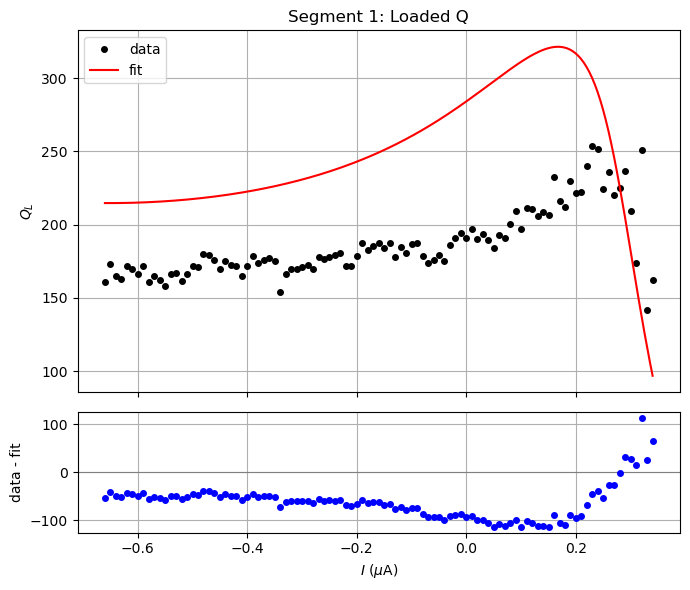

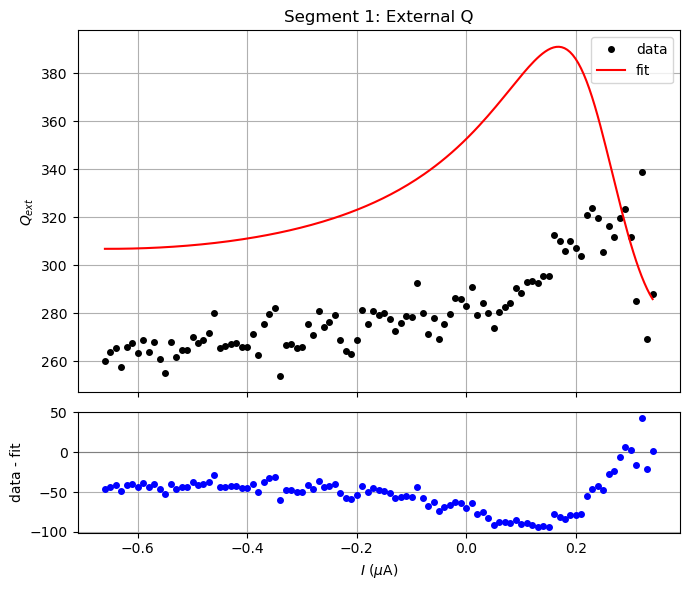

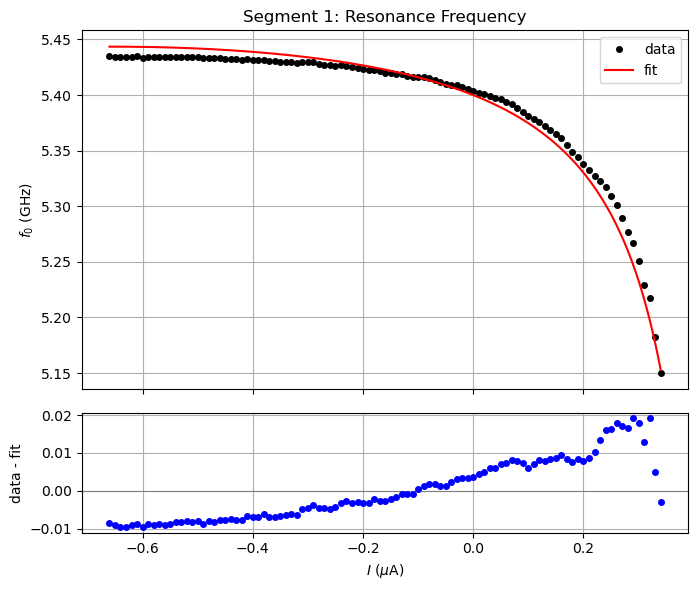

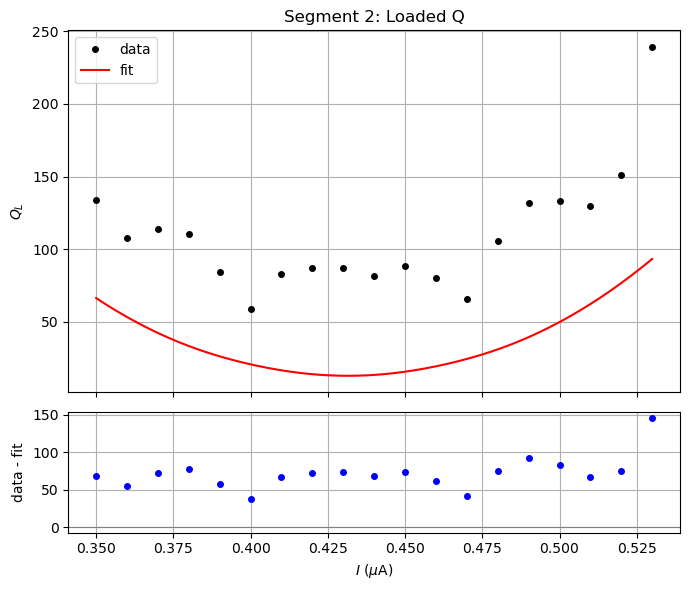

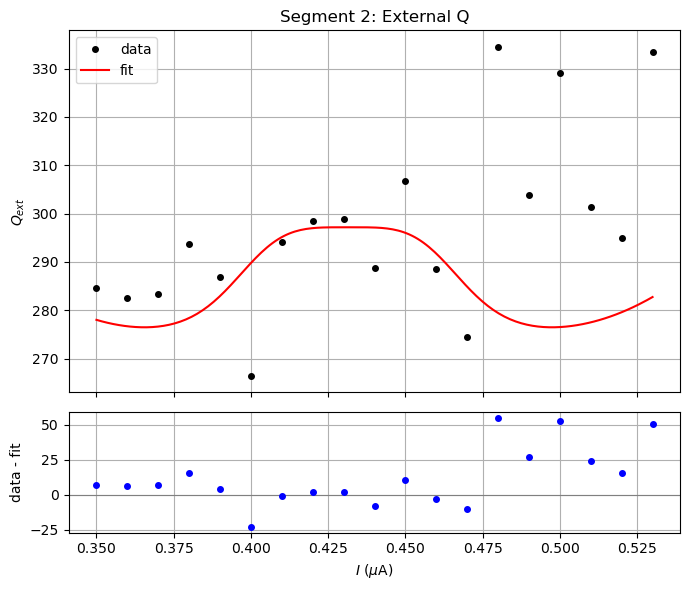

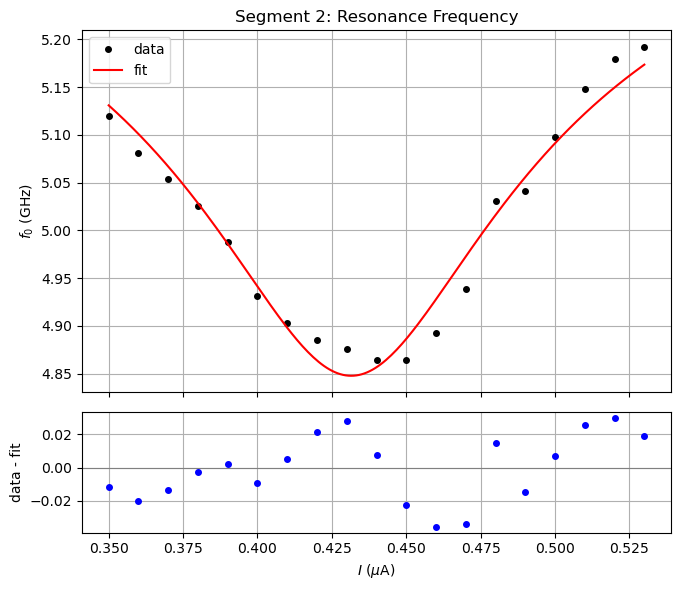

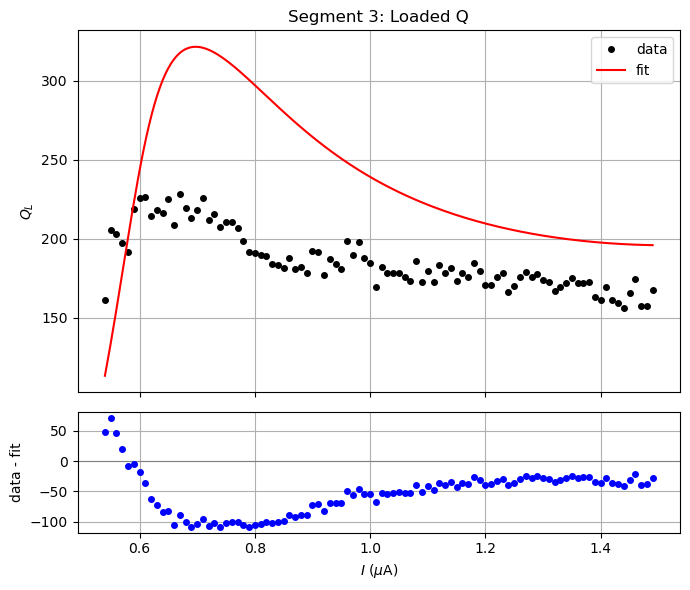

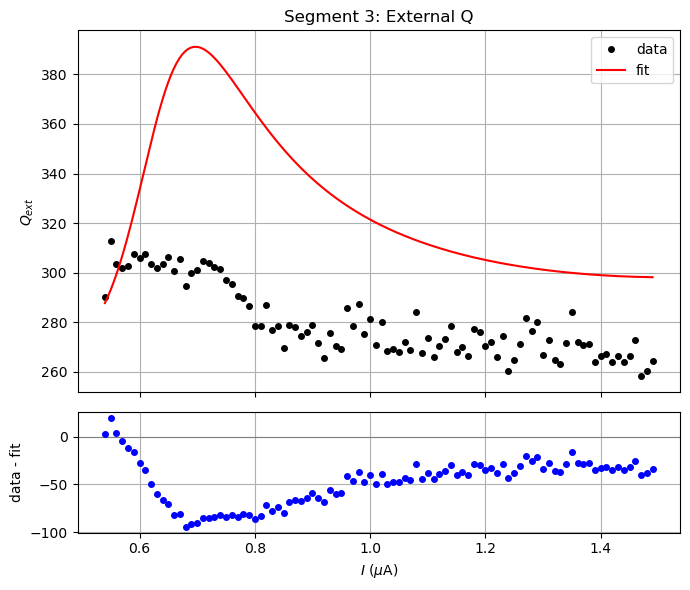

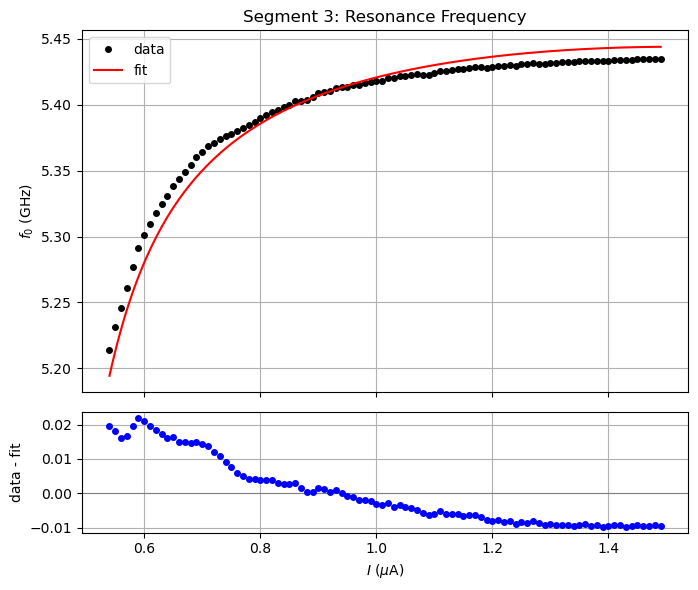

In [40]:
def plot_fit_with_error(I_uA, data, model_dense_I_uA, model_dense_vals, model_at_data,
                          ylabel, title, log_y=False):
    fig, (ax_main, ax_err) = plt.subplots(
        2, 1, figsize=(7, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]}
    )

    ax_main.plot(I_uA, data, 'ko', ms=4, label='data')
    ax_main.plot(model_dense_I_uA, model_dense_vals, 'r-', lw=1.5, label='fit')
    if log_y:
        ax_main.set_yscale('log')
    ax_main.set_ylabel(ylabel)
    ax_main.set_title(title)
    ax_main.legend()
    ax_main.grid(True)

    if log_y:
        error = np.log10(data) - np.log10(model_at_data)
        err_label = 'log10(data) - log10(fit)'
    else:
        error = data - model_at_data
        err_label = 'data - fit'

    ax_err.axhline(0, color='gray', lw=0.8)
    ax_err.plot(I_uA, error, 'bo', ms=4)
    ax_err.set_ylabel(err_label)
    ax_err.set_xlabel(r'$I$ ($\mu$A)')
    ax_err.grid(True)

    plt.tight_layout()
    plt.show()


for seg_name, res_dict in results_by_segment.items():
    popt = res_dict['popt']
    I_uA = res_dict['I_seg']

    I_dense_uA = np.linspace(I_uA.min(), I_uA.max(), 200)
    I_dense_A = I_dense_uA * 1e-6

    QL_dense, qi_dense, qe_dense, f0_dense = model_q_factors(
        I_dense_A, L0_f, LT_f, Ll_f, Cl_f, popt[0], popt[1], M_f, O_fixed, R_L, (Freq.min(), Freq.max())
    )
    QL_at_data, qi_at_data, qe_at_data, f0_at_data = model_q_factors(
        I_uA*1e-6, L0_f, LT_f, Ll_f, Cl_f, popt[0], popt[1], M_f, O_fixed, R_L, (Freq.min(), Freq.max())
    )

    plot_fit_with_error(
        I_uA, res_dict['QL_seg'], I_dense_uA, QL_dense, QL_at_data,
        ylabel=r'$Q_L$', title=f'{seg_name}: Loaded Q'
    )
    plot_fit_with_error(
        I_uA, res_dict['Qe_seg'], I_dense_uA, qe_dense, qe_at_data,
        ylabel=r'$Q_{ext}$', title=f'{seg_name}: External Q'
    )
    plot_fit_with_error(
        I_uA, res_dict['f0_seg']/1e9, I_dense_uA, f0_dense/1e9, f0_at_data/1e9,
        ylabel=r'$f_0$ (GHz)', title=f'{seg_name}: Resonance Frequency'
    )